In [68]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors
import geopandas as gpd
from shapely.geometry import Polygon, Point

from unidecode import unidecode

In [69]:
# parameters
region_level = "nuts4"
industry_level = "nace3d"
year = 2017

**R1.1 -- co-located supplier patterns**

In [70]:
# matrix 1 -- average IO relatedness for coagglomerated and skill related industries

# SR and coagglomeration table
ii_reg = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_level}_{year}.csv", sep=";")

def ind_ind_variables(df, colocation_variable):
    """function to speed up test with different coagglomeration measures"""
    df["sr01"] = (df["sr_norm"] > 0).astype(int)
    #df["colocation_median01"] = (df[colocation_variable] > df[colocation_variable].median()).astype(int)
    df["colocation01"] = (df[colocation_variable] > 0).astype(int)
    return df

ii_table = ind_ind_variables(ii_reg, colocation_variable="coagg_porter_rca01")
ii_table["io01"] = (ii_table["io_norm3"] > 0).astype(int)

# make a clean matrix
ii_mat = pd.pivot_table(ii_table,
        #values="io_norm3",
        values="io01",
        index="sr01",
        columns="colocation01",
        aggfunc="mean",
        margins=False)

#ff_mat_norm = ff_mat / ff_mat.sum().sum()
ii_mat.sort_values(by="sr01", ascending=False, inplace=True)

In [71]:
# matrix 3 -- supplier ties inside regions (co-location) between firms in SR and not SR industries
ddf = pd.read_csv("../data/oc15_2023_dec/oc_distance_io_labor_ties.csv", sep=";")
ddf["nr_io_no_sr_ties"] = ddf["nr_io_ties"] - ddf["nr_io_sr_ties"]

# sum up ties, where distance > 0 (aka not the same region)
dist_0_row = ddf[ddf["dist_int"] == 0]
dist_0_row["colocation"] = 1
dist_above_0_rows = ddf[ddf["dist_int"] > 0]
summed_row = dist_above_0_rows.sum(numeric_only=True)
summed_row["colocation"] = 0

# combine
inreg = pd.concat([dist_0_row, pd.DataFrame([summed_row])], ignore_index=True)
inreg = inreg[["colocation", "nr_io_sr_ties", "nr_io_no_sr_ties"]]

# clean
inreg["colocation"] = inreg["colocation"].astype(int)
inreg.sort_values(by="colocation", ascending=True, inplace=True)
inreg.set_index("colocation", inplace=True)
inreg.columns = [1, 0]
inreg.columns.name = "sr01"
inreg = inreg.T.sort_values(by="sr01", ascending=False)
inreg_mat = (inreg / inreg.sum().sum())

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_4544/3245892986.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dist_0_row["colocation"] = 1


In [82]:
# matrix 2 -- supplier ties inside regions (co-location) between firms in SR and not SR industries
selected_dist = 10
ddf = pd.read_csv("../data/oc15_2023_dec/oc_distance_io_labor_ties.csv", sep=";")
ddf["nr_io_no_sr_ties"] = ddf["nr_io_ties"] - ddf["nr_io_sr_ties"]

ddf["colocation01"] = (ddf["dist_int"] <= selected_dist).astype(int)

# define a distance
table_d = ddf.groupby(["colocation01"]).agg(
    nr_io_sr_ties = pd.NamedAgg("nr_io_sr_ties", "sum"),
    nr_io_no_sr_ties = pd.NamedAgg("nr_io_no_sr_ties", "sum")
)

table_d.sort_values(by="colocation01", ascending=True, inplace=True)
#inreg.set_index("colocation01", inplace=True)
table_d.columns = [1, 0]
table_d.columns.name = "sr01"
table_d = table_d.T.sort_values(by="sr01", ascending=False)
table_d = (table_d / table_d.sum().sum())

In [83]:
def crosstab_visual(mat, fontsize, colormap, title_text=None, axis_labels=None, ax=None):
    if ax is None:
        ax = plt.gca()
    mh = sns.heatmap(
        mat,
        annot=True,
        annot_kws={"fontsize":(fontsize)},
        fmt=".2f",
        cbar=False,
        cmap=colormap,
        ax=ax
    )

    if axis_labels:
        ax.set_xlabel(axis_labels[0], fontsize=fontsize)
        ax.set_ylabel(axis_labels[1], fontsize=fontsize)
    
    if title_text:
        ax.set_title(title_text, fontsize=fontsize)
        

In [84]:
table_d

colocation01,0,1
sr01,,
1,0.372089,0.188029
0,0.302585,0.137297


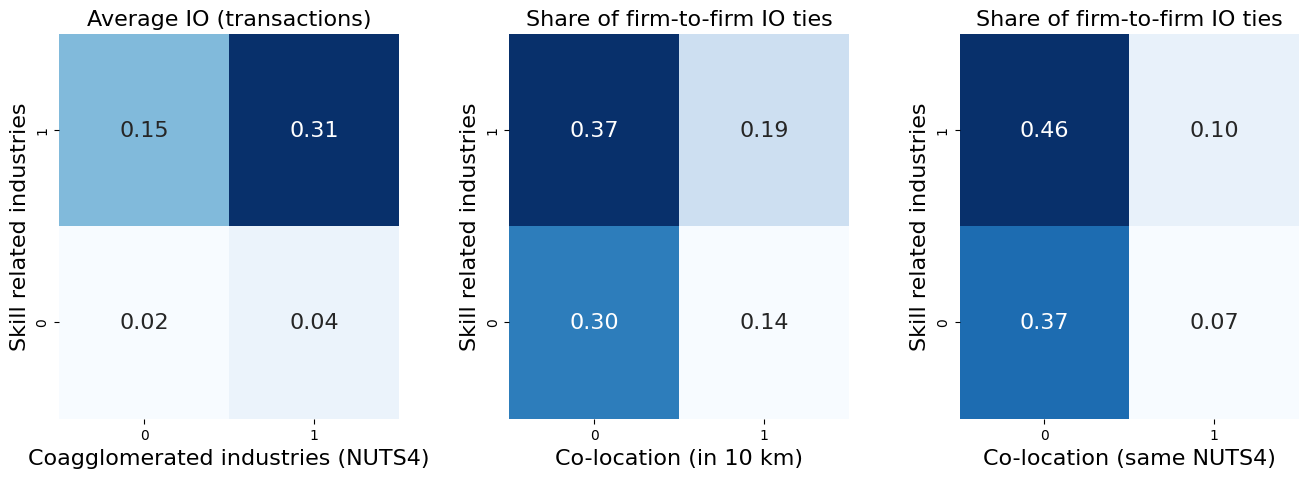

In [85]:
fig, ax = plt.subplots(1,3, figsize=(16,5))
plt.subplots_adjust(wspace=0.325)
fontsize = 16

crosstab_visual(
    ii_mat,
    fontsize=fontsize,
    colormap="Blues",
    title_text="Average IO (transactions)",
    axis_labels=["Coagglomerated industries (NUTS4)", "Skill related industries"],
    ax=ax[0]
)

crosstab_visual(
    table_d,
    fontsize=fontsize,
    colormap="Blues",
    title_text="Share of firm-to-firm IO ties",
    axis_labels=[f"Co-location (in {selected_dist} km)", "Skill related industries"],
    ax=ax[1]
)

crosstab_visual(
    inreg_mat,
    fontsize=fontsize,
    colormap="Blues",
    title_text="Share of firm-to-firm IO ties",
    axis_labels=["Co-location (same NUTS4)", "Skill related industries"],
    ax=ax[2]
) 

**R1.6 and R1.10 -- co-patenting and patent citations**

In [98]:
def matrix_represantation(df, key_columns, sort_matrix, heatmap, fontsize, title_text, cmap, cbar_label, ax=None):
    """matrix or pivot table representation of our key variables"""
    table = df[key_columns]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_columns]
    table = pd.concat([table, table2])

    # pivot transformation
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[0],
        columns=key_columns[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    # option to sort the matrix
    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
    
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    # option to keep the table or create heatmap
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(
            table,
            cbar=True,
            cmap=cmap,
            ax=ax
        )
        ax.figure.axes[-1].set_ylabel(cbar_label, size=fontsize-5)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_title(title_text, size=fontsize)

        labels = table.index.tolist()  # Get row index labels
        tick_positions = [i + 0.5 for i in range(len(labels)) if i % 4 == 0]
        tick_labels = [labels[i] for i in range(len(labels)) if i % 4 == 0]

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=90, fontsize=fontsize-10)

        ax.set_yticks(tick_positions)
        ax.set_yticklabels(tick_labels, rotation=0, fontsize=fontsize-10)
        
        # Remove tick lines
        ax.tick_params(left=False, bottom=False)
        #ax.yaxis.set_tick_params(rotation=0, labelbottom=True)
        #ax.tick_params(left = False, bottom = False)

In [99]:
# KDE plots to illustrate distribution
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [100]:
# citation based relatedness of 2-digit industries -- constructed in 06_revision.R
cr_table = pd.read_csv("../outputs/cr_norm_citation.csv", sep=";")
cr_table.rename(columns={"ind_i":"ind1", "ind_j":"ind2"}, inplace=True)
cr_table = cr_table[cr_table["ind1"] < cr_table["ind2"]]

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_4544/2790579632.py:11: FutureWarning: The provided callable <function max at 0x10c3037e0> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_4544/2790579632.py:11: FutureWarning: The provided callable <function max at 0x10c3037e0> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_4544/2790579632.py:11: FutureWarning: The provided callable <function max at 0x10c3037e0> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior p

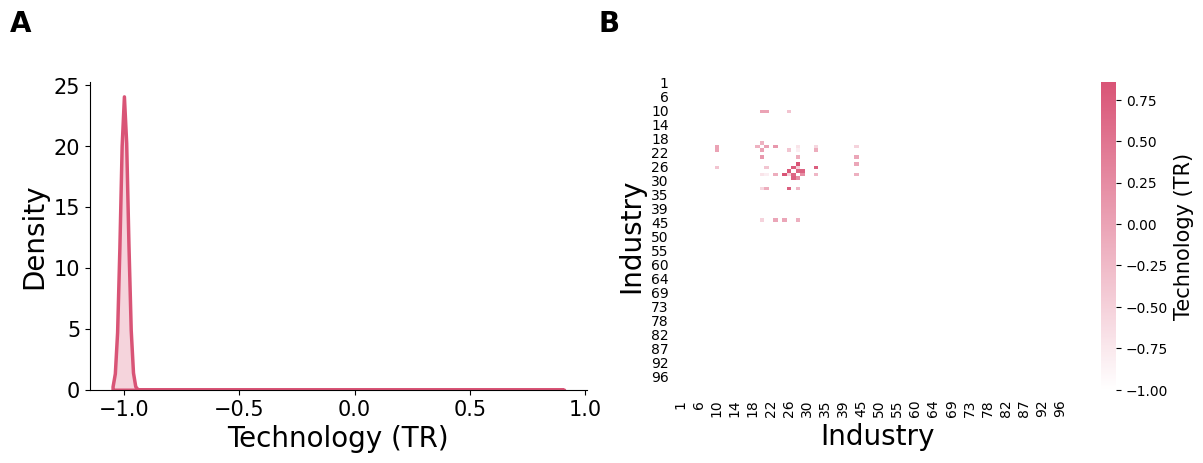

In [103]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "cr_norm"

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#D95476"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

density_plot(
    cr_table,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Tech (TR)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    cr_table,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Tech (TR)",
    ax=ax[1]
)
ax[1].xaxis.set_tick_params(rotation=90, labelbottom=True)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/revision_technology_distribution.png", dpi=300, bbox_inches='tight', facecolor="white")

**interplots including citation data**

In [104]:
# data from /code/95b_regressions_main.R
mf_df = pd.read_csv("../outputs/marginal_effects_for_interplots_with_citations.csv", sep=";")

In [105]:
def custom_interplot(df, setting_vector, fontsize, ax=None):
    df = df[(df["dep_var"]==setting_vector[0]) & (df["y_values"]==setting_vector[1]) & (df["x_var"]==setting_vector[2])]
    
    if ax is None: 
        ax = plt.gca()
    ax.plot(df["x_values"], df["AME"], color="black", zorder=4)
    ax.plot(df["x_values"], df["upper"], color="#15636A", zorder=4)
    ax.plot(df["x_values"], df["lower"], color="#15636A", zorder=4)
    ax.fill_between(df["x_values"], df["lower"], df["upper"], color="#15636A", alpha=0.3, zorder=3)
    ax.axhline(y=0, color='black', linestyle='--', zorder=2)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

Text(-125, 75, 'H')

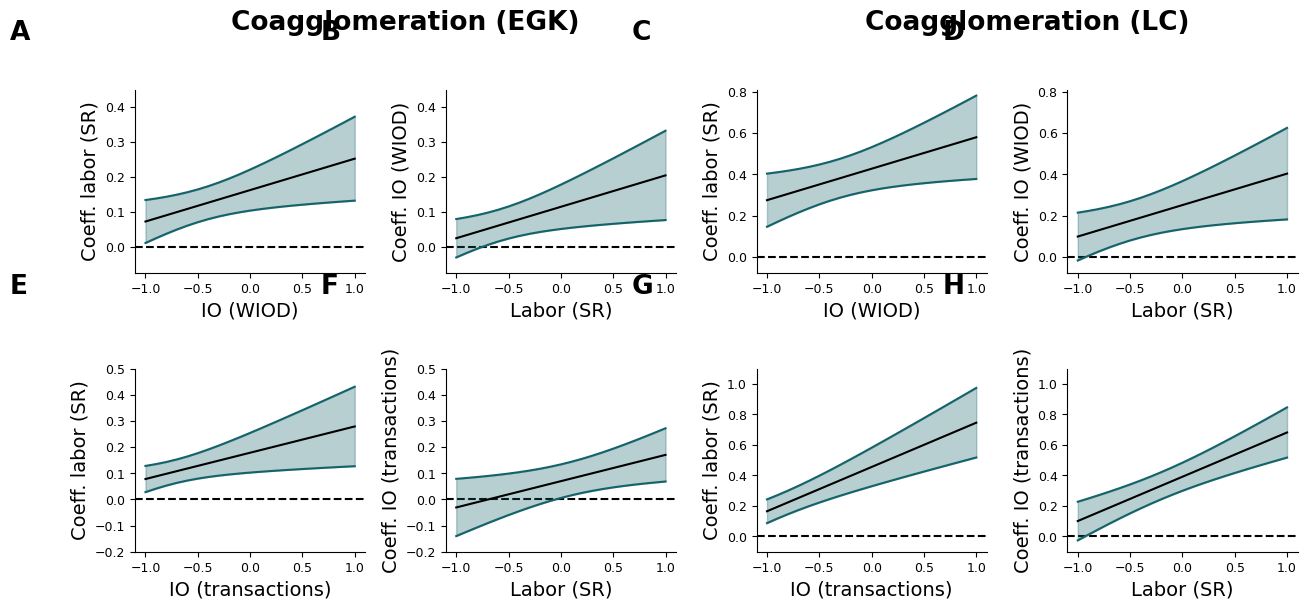

In [109]:
fig, ax = plt.subplots(2,4, figsize=(15, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.525)
fontsize=14


title_text = "Coagglomeration (EGK)"
fig.text((ax[0, 0].get_position().x0 + ax[0, 1].get_position().x1) / 2, 
         ax[0, 0].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)
title_text = "Coagglomeration (LC)"
fig.text((ax[0, 2].get_position().x0 + ax[0, 3].get_position().x1) / 2, 
         ax[0, 2].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,0])
ax[0,0].set_ylim(-0.075, 0.45)
ax[0,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,0].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,1])
ax[0,1].set_ylim(-0.075, 0.45)
ax[0,1].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,0])
ax[1,0].set_ylim(-0.2, 0.5)
ax[1,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,0].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,1])
ax[1,1].set_ylim(-0.2, 0.5)
ax[1,1].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,2])
ax[0,2].set_ylim(-0.075, 0.81)
ax[0,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,2].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,3])
ax[0,3].set_ylim(-0.075, 0.81)
ax[0,3].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,3].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,2])
ax[1,2].set_ylim(-0.1, 1.1)
ax[1,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,2].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,3])
ax[1,3].set_ylim(-0.1, 1.1)
ax[1,3].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,3].set_xlabel("Labor (SR)", size=fontsize)

ax[0,0].annotate("A", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,1].annotate("B", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,2].annotate("C", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,3].annotate("D", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,0].annotate("E", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,1].annotate("F", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,2].annotate("G", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,3].annotate("H", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)

# plt.savefig(f"../figures/revision_interplots_with_tech.png", dpi=300, bbox_inches='tight', facecolor="white")

**R1.x -- compare region sizes**

In [227]:
# shape IN
nuts3_gdf = gpd.read_file(f"../data/shape_files/nuts3_shape.geojson")
nuts4_gdf = gpd.read_file(f"../data/shape_files/nuts4_shape.geojson")

In [236]:
# size of regions
nuts3_gdf["polygon_size"] = nuts3_gdf["geometry"].area
nuts4_gdf["polygon_size"] = nuts4_gdf["geometry"].area

In [238]:
nuts3_gdf.crs

<Projected CRS: EPSG:3785>
Name: Popular Visualisation CRS / Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Mercator
- method: Mercator (1SP) (Spherical)
Datum: Popular Visualisation Datum
- Ellipsoid: Popular Visualisation Sphere
- Prime Meridian: Greenwich

<Axes: >

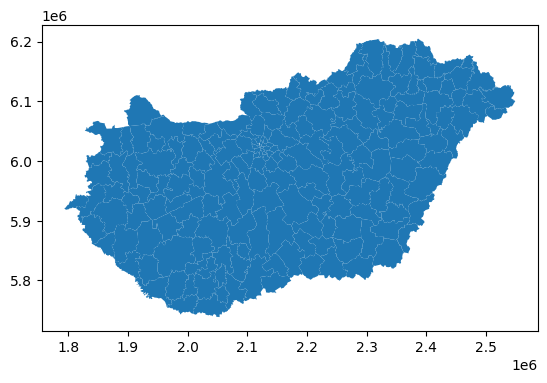

In [230]:
nuts4_gdf.plot()